**Goal:** assemble the single attention operation from L21 into the architecture that powers every
large language model. You will build **multi-head attention**, **positional encoding**, and the
**residual + layer-norm encoder block** -- all from L21's own `attention` function -- then train a
small **Transformer** on an order-dependent task and watch positional encoding flip it from chance to
solved. That is the exact gap L21 left open: pure attention is order-blind, and position is what it was
missing. Everything runs on CPU in about ten seconds. Pairs with the concept note
[The Transformer Architecture](l22_concept_transformers.qmd).

> **Previously:** L21 -- Attention Mechanisms (one attention layer, order-blind)  |  **Next:** L23 -- K-Means Clustering & Similarity (Unit VI)

> This page is the read-only view. To run the lab, open the notebook
> (`l22_lab_transformers.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

L21 built one attention layer and found its one flaw: it is **order-blind**. Shuffle the input and the
output is identical, so "dog bites man" and "man bites dog" look the same. Everything else about a
Transformer -- several attention heads, residual + layer-norm blocks, a stack of them -- is
engineering around the core operation you already have. The one genuinely new idea is **positional
encoding**: a way to tell the set-based attention layer where each token sits. We build the pieces,
stack them into a Transformer, and prove on an order-dependent task that position is the missing
ingredient.

## Setup

Two cells: the first installs, the second imports and seeds. There is no dataset to download -- every
tensor in this lab is built in the notebook.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships these, so this is effectively a no-op there.
%pip install -q torch matplotlib
# local, in a terminal (not in the notebook):  uv add torch matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS + SEEDS (safe to re-run without re-installing)
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
np.set_printoptions(precision=3, suppress=True)
print("setup ready -", "GPU" if torch.cuda.is_available() else "CPU")

setup ready - CPU


~~~text
setup ready - CPU
~~~

## Step 1: Multi-Head Attention

L21's attention let every token gather from the whole sequence in one weighted blend. But one blend
can only track one kind of relationship at a time. **Multi-head attention** runs several attentions in
**parallel**: split the width `d` into `h` slices of size `d/h`, run an independent attention in each
**head**, then concatenate the results. Different heads can specialize -- one on the previous word,
another on a distant noun -- and a final linear layer `Wo` mixes them. We reuse L21's `attention`
verbatim (now with an optional mask, for Exercise 1):

In [3]:
def attention(Q, K, V, mask=None):
    """softmax(Q K^T / sqrt(d_k)) V. Optional additive mask is added to the scores before softmax."""
    d_k = Q.shape[-1]
    scores = (Q @ K.transpose(-2, -1)) / (d_k ** 0.5)
    if mask is not None:
        scores = scores + mask
    weights = scores.softmax(dim=-1)
    return weights @ V, weights

class MultiHeadSelfAttention(nn.Module):
    """h attention heads in parallel: split d into h slices of size d/h, attend in each, concat."""
    def __init__(self, d, n_heads):
        super().__init__()
        assert d % n_heads == 0, "d must divide evenly into n_heads"
        self.n_heads, self.d_head = n_heads, d // n_heads
        self.Wq = nn.Linear(d, d); self.Wk = nn.Linear(d, d); self.Wv = nn.Linear(d, d)
        self.Wo = nn.Linear(d, d)
    def _split(self, t):                      # (B, L, d) -> (B, h, L, d_head)
        B, L, _ = t.shape
        return t.view(B, L, self.n_heads, self.d_head).transpose(1, 2)
    def forward(self, x, mask=None, return_attn=False):
        B, L, d = x.shape
        q, k, v = self._split(self.Wq(x)), self._split(self.Wk(x)), self._split(self.Wv(x))
        ctx, w = attention(q, k, v, mask=mask)                # attend within every head
        ctx = ctx.transpose(1, 2).contiguous().view(B, L, d)  # concat the heads back to width d
        out = self.Wo(ctx)
        return (out, w) if return_attn else out

torch.manual_seed(0)
mha = MultiHeadSelfAttention(d=64, n_heads=4)
x = torch.randn(1, 5, 64)                                     # one sequence of 5 tokens, width 64
out, w = mha(x, return_attn=True)
print("input shape:", tuple(x.shape), "-> output shape:", tuple(out.shape))
print("attention weights shape:", tuple(w.shape), "= (batch, heads, query, key)")
print("token 0, head 0 attends:", w[0, 0, 0].detach().numpy())
print("token 0, head 1 attends:", w[0, 1, 0].detach().numpy())

input shape: (1, 5, 64) -> output shape: (1, 5, 64)
attention weights shape: (1, 4, 5, 5) = (batch, heads, query, key)
token 0, head 0 attends: [0.198 0.148 0.239 0.199 0.216]
token 0, head 1 attends: [0.181 0.226 0.267 0.212 0.115]


~~~text
input shape: (1, 5, 64) -> output shape: (1, 5, 64)
attention weights shape: (1, 4, 5, 5) = (batch, heads, query, key)
token 0, head 0 attends: [0.198 0.148 0.239 0.199 0.216]
token 0, head 1 attends: [0.181 0.226 0.267 0.212 0.115]
~~~

The output keeps the input shape `(1, 5, 64)`, but there are now **four** separate `5 x 5` attention
matrices -- one per head -- and token 0 attends differently in head 0 than in head 1 (0.239 vs 0.267
on its strongest position). Four heads, four views of the sequence, concatenated. PyTorch ships this
as `nn.MultiheadAttention`; ours is the same computation unrolled.

## Step 2: Positional Encoding

Attention is a **set** operation -- it has no built-in notion of position. To give it one, add a
**position signal** to each token embedding before the first block. The original Transformer uses fixed
**sinusoidal** encodings: each dimension is a sine or cosine of the position at a different frequency,
so every position gets a unique, smoothly varying fingerprint.

In [4]:
def sinusoidal_pos_encoding(max_len, d):
    """Vaswani et al. position signal: sines/cosines of geometrically spaced frequencies."""
    pos = torch.arange(max_len).unsqueeze(1).float()
    i = torch.arange(0, d, 2).float()
    div = torch.exp(-math.log(10000.0) * i / d)
    pe = torch.zeros(max_len, d)
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

pe = sinusoidal_pos_encoding(max_len=16, d=64)
print("positional encoding shape:", tuple(pe.shape))
print("PE[position 0, first 6 dims]:", pe[0, :6].numpy())
print("PE[position 1, first 6 dims]:", pe[1, :6].numpy())

same = torch.ones(1, 3, 64)                                  # three IDENTICAL token vectors
print("without PE, positions 0,1,2 identical:",
      bool(torch.allclose(same[0, 0], same[0, 1]) and torch.allclose(same[0, 1], same[0, 2])))
withpe = same + pe[:3]
print("with PE, position 0 vs 1 now differ:", bool(not torch.allclose(withpe[0, 0], withpe[0, 1])))

positional encoding shape: (16, 64)
PE[position 0, first 6 dims]: [0. 1. 0. 1. 0. 1.]
PE[position 1, first 6 dims]: [0.841 0.54  0.682 0.732 0.533 0.846]
without PE, positions 0,1,2 identical: True
with PE, position 0 vs 1 now differ: True


~~~text
positional encoding shape: (16, 64)
PE[position 0, first 6 dims]: [0. 1. 0. 1. 0. 1.]
PE[position 1, first 6 dims]: [0.841 0.54  0.682 0.732 0.533 0.846]
without PE, positions 0,1,2 identical: True
with PE, position 0 vs 1 now differ: True
~~~

Three identical token vectors are indistinguishable to attention -- until we add the positional
encoding, after which positions 0 and 1 differ. That is the whole trick: position becomes part of the
representation. The encoding matrix itself is a set of stacked waves:

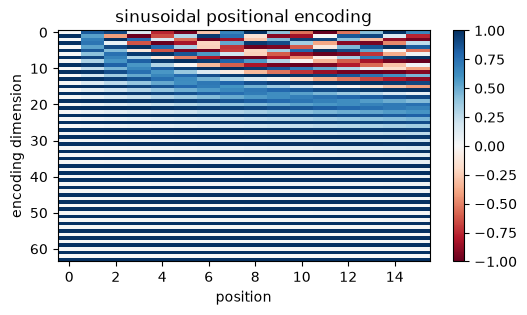

In [5]:
plt.figure(figsize=(6, 3))
plt.imshow(pe.numpy().T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
plt.xlabel("position"); plt.ylabel("encoding dimension")
plt.title("sinusoidal positional encoding"); plt.colorbar(); plt.show()

Low dimensions oscillate fast (they separate neighbors); high dimensions oscillate slowly (they
separate far-apart positions). Together they give every position a distinct code.

## Step 3: The Transformer Encoder Block

Now the block that gets stacked. It is two sublayers, each wrapped the same way -- a **residual
connection** (the L19 idea: add the input back, so each sublayer only has to learn a *change*) followed
by **layer normalization** (new here: it standardizes each token across its features, unlike L17's
batch-norm which standardized across the batch). The two sublayers are **multi-head self-attention**
(mix information between positions) and a **position-wise feed-forward network** (an MLP applied to
each position independently, for per-token nonlinearity):

In [6]:
class EncoderBlock(nn.Module):
    """multi-head self-attention -> Add & Norm -> position-wise feed-forward -> Add & Norm."""
    def __init__(self, d, n_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d, n_heads)
        self.norm1 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, d_ff), nn.ReLU(), nn.Linear(d_ff, d))
        self.norm2 = nn.LayerNorm(d)
    def forward(self, x, mask=None):
        x = self.norm1(x + self.attn(x, mask=mask))          # residual connection + layer norm
        x = self.norm2(x + self.ff(x))                       # residual connection + layer norm
        return x

torch.manual_seed(0)
block = EncoderBlock(d=64, n_heads=4, d_ff=128)
h = block(torch.randn(2, 12, 64))
print("block input shape: (2, 12, 64) -> output shape:", tuple(h.shape))

block input shape: (2, 12, 64) -> output shape: (2, 12, 64)


~~~text
block input shape: (2, 12, 64) -> output shape: (2, 12, 64)
~~~

A block maps a sequence to a same-shape sequence, so blocks stack cleanly. `nn.TransformerEncoderLayer`
is exactly this block, production-tuned.

In [7]:
# Your turn (warm-up): the block has 4 attention projections Linear(64,64), two LayerNorm(64), and a
# feed-forward Linear(64,128) + Linear(128,64). Predict its total parameter count, then check.
# Uncomment and fill the blank:
# print("block parameters:", sum(p.numel() for p in block.parameters()))   # expect ____

The block has **33,472** parameters: `4 * (64*64 + 64) = 16,640` for the attention projections,
`(64*128 + 128) + (128*64 + 64) = 16,576` for the feed-forward network, and `2 * (2*64) = 256` for the
two layer norms. Most of a Transformer's weight is in exactly these two sublayers.

## Step 4: Build the Transformer and Train It on Order

Here is the payoff. The task: each sequence is a `CLS` token (position 0) followed by filler tokens,
with exactly one marker **A** and one marker **B** dropped at two random positions. The label is
**1 if A comes before B**, else 0. Crucially, the *multiset* of tokens is identical either way -- only
the **order** distinguishes the classes -- so a model with no sense of position is provably stuck at
chance (0.50).

In [8]:
def make_order_dataset(n, seq_len=12, vocab=10, seed=0):
    """'Does marker A come before marker B?' CLS at position 0; one A (token 1) and one B (token 2)
    at two distinct random positions; fillers elsewhere. label = 1 if pos(A) < pos(B) else 0.
    The token MULTISET is identical either way, so order is the ONLY signal."""
    g = torch.Generator().manual_seed(seed)
    CLS, A, B = 0, 1, 2
    x = torch.zeros(n, seq_len, dtype=torch.long)
    y = torch.zeros(n, dtype=torch.long)
    for i in range(n):
        seq = torch.randint(3, vocab, (seq_len,), generator=g)   # fillers
        seq[0] = CLS
        p = torch.randperm(seq_len - 1, generator=g)[:2] + 1      # two distinct content positions
        pa, pb = p[0].item(), p[1].item()
        seq[pa] = A; seq[pb] = B
        x[i] = seq
        y[i] = 1 if pa < pb else 0
    return x, y

xtr, ytr = make_order_dataset(4000, seed=0)
xte, yte = make_order_dataset(1000, seed=1)
print("train", tuple(xtr.shape), "test", tuple(xte.shape), "| label balance (test):",
      round(yte.float().mean().item(), 3))
print("example 0:", xtr[0].tolist(), "-> A before B? y =", ytr[0].item())

train (4000, 12) test (1000, 12) | label balance (test): 0.517
example 0: [0, 6, 3, 1, 4, 5, 9, 6, 7, 8, 5, 2] -> A before B? y = 1


~~~text
train (4000, 12) test (1000, 12) | label balance (test): 0.517
example 0: [0, 6, 3, 1, 4, 5, 9, 6, 7, 8, 5, 2] -> A before B? y = 1
~~~

In example 0 the marker `1` (A) sits at position 3 and `2` (B) at position 11, so A is before B and
the label is 1. The full model is a token embedding, an optional positional encoding, a stack of
encoder blocks, and a classifier reading from the `CLS` position. We train it twice -- once **without**
positional encoding, once **with** -- changing nothing else:

In [9]:
class TinyTransformer(nn.Module):
    def __init__(self, vocab, d=64, n_heads=4, n_blocks=2, d_ff=128, max_len=16,
                 pos_mode="sinusoidal"):
        super().__init__()
        self.pos_mode = pos_mode
        self.tok_emb = nn.Embedding(vocab, d)
        if pos_mode == "sinusoidal":
            self.register_buffer("pe", sinusoidal_pos_encoding(max_len, d))
        elif pos_mode == "learned":
            self.pos_emb = nn.Embedding(max_len, d)
        self.blocks = nn.ModuleList([EncoderBlock(d, n_heads, d_ff) for _ in range(n_blocks)])
        self.head = nn.Linear(d, 2)
    def forward(self, x):
        L = x.shape[1]
        h = self.tok_emb(x)
        if self.pos_mode == "sinusoidal":
            h = h + self.pe[:L]
        elif self.pos_mode == "learned":
            h = h + self.pos_emb(torch.arange(L))
        for blk in self.blocks:
            h = blk(h)
        return self.head(h[:, 0])                            # classify from the CLS position

def train(model, xtr, ytr, xte, yte, epochs=15, bs=256):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3); loss_fn = nn.CrossEntropyLoss()
    n = len(ytr)
    for epoch in range(epochs):
        g = torch.Generator().manual_seed(epoch)
        perm = torch.randperm(n, generator=g)
        model.train()
        for s in range(0, n, bs):
            b = perm[s:s + bs]
            opt.zero_grad(); loss_fn(model(xtr[b]), ytr[b]).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        return (model(xte).argmax(1) == yte).float().mean().item()

torch.manual_seed(0)
no_pos = TinyTransformer(vocab=10, pos_mode="none")
acc_no = train(no_pos, xtr, ytr, xte, yte)
torch.manual_seed(0)
with_pos = TinyTransformer(vocab=10, pos_mode="sinusoidal")
acc_pe = train(with_pos, xtr, ytr, xte, yte)
print(f"NO positional encoding:   {acc_no:.4f}   (chance = 0.5)")
print(f"WITH positional encoding: {acc_pe:.4f}")

NO positional encoding:   0.4800   (chance = 0.5)
WITH positional encoding: 1.0000


~~~text
NO positional encoding:   0.4800   (chance = 0.5)
WITH positional encoding: 1.0000
~~~

The same architecture, the same data, the same training -- yet without positional encoding the model
is **at chance**, and with it the model is **perfect**. Position was the whole difference. We can show
*why* the no-position model fails: it is order-blind, so shuffling the tokens leaves its prediction
exactly unchanged.

In [10]:
torch.manual_seed(1)
perm = torch.cat([torch.tensor([0]), torch.randperm(11) + 1])   # keep CLS at 0, shuffle the rest
with torch.no_grad():
    a, b = no_pos(xte[:1]), no_pos(xte[:1, perm])
    c, d = with_pos(xte[:1]), with_pos(xte[:1, perm])
print("no-PE  logits identical after shuffling positions:", bool(torch.allclose(a, b, atol=1e-5)))
print("PE     logits identical after shuffling positions:", bool(torch.allclose(c, d, atol=1e-5)))

no-PE  logits identical after shuffling positions: True
PE     logits identical after shuffling positions: False


~~~text
no-PE  logits identical after shuffling positions: True
PE     logits identical after shuffling positions: False
~~~

The no-position model gives **bit-identical** logits whether or not we shuffle -- it literally cannot
see order, so it can never tell A-before-B from B-before-A. Adding positional encoding breaks that
symmetry, and the task becomes solvable. That is the Transformer in one experiment: attention for
reach, position for order, blocks to stack it deep.

## Your Turn

### Exercise 1 -- Causal masking (how GPT reads)

An **encoder** lets every position see every other. A **decoder** that generates text left to right must
not peek at the future. The fix is a **causal mask**: add `-inf` to every score above the diagonal, so
the softmax zeros out future positions. Apply a causal mask to `MultiHeadSelfAttention` on a length-6
input and print the attention matrix of head 0. Confirm it is lower-triangular and each row still sums
to 1.

**Hint:** build `mask = torch.triu(torch.full((6, 6), float("-inf")), diagonal=1)`; pass it as
`mha(x, mask=mask, return_attn=True)`; the weights are `w[0, 0]` for head 0.

In [11]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
causal attention (head 0) -- each position attends only to itself and earlier:
[[1.    0.    0.    0.    0.    0.   ]
 [0.572 0.428 0.    0.    0.    0.   ]
 [0.282 0.455 0.263 0.    0.    0.   ]
 [0.211 0.275 0.179 0.335 0.    0.   ]
 [0.135 0.18  0.163 0.258 0.264 0.   ]
 [0.113 0.259 0.102 0.224 0.183 0.119]]
row sums: [1. 1. 1. 1. 1. 1.] | weight in the future (upper triangle): 0.0
~~~

Position 0 can only attend to itself (weight 1.0); position 5 attends over all six. Every row sums to
1, and there is exactly **zero** weight above the diagonal -- no position sees the future. This single
mask is the only structural difference between a BERT-style encoder (bidirectional) and a GPT-style
decoder (causal, generates one token at a time).

In [12]:
torch.manual_seed(0)
mask = torch.triu(torch.full((6, 6), float("-inf")), diagonal=1)
mha_c = MultiHeadSelfAttention(d=64, n_heads=4)
_, wc = mha_c(torch.randn(1, 6, 64), mask=mask, return_attn=True)
print("causal attention (head 0) -- each position attends only to itself and earlier:")
print(wc[0, 0].detach().numpy())
print("row sums:", wc[0, 0].sum(-1).detach().numpy(),
      "| weight in the future (upper triangle):", wc[0, 0].triu(1).sum().item())

causal attention (head 0) -- each position attends only to itself and earlier:
[[1.    0.    0.    0.    0.    0.   ]
 [0.572 0.428 0.    0.    0.    0.   ]
 [0.282 0.455 0.263 0.    0.    0.   ]
 [0.211 0.275 0.179 0.335 0.    0.   ]
 [0.135 0.18  0.163 0.258 0.264 0.   ]
 [0.113 0.259 0.102 0.224 0.183 0.119]]
row sums: [1. 1. 1. 1. 1. 1.] | weight in the future (upper triangle): 0.0


</details>

### Exercise 2 -- A learned positional encoding

Sinusoidal encodings are fixed. Most modern LLMs instead **learn** the position signal: a trainable
`nn.Embedding(max_len, d)` looked up by position, exactly like a token embedding. Our `TinyTransformer`
already supports it with `pos_mode="learned"`. Train one and report its accuracy on the order task.
Does a learned signal also crack it?

**Hint:** `torch.manual_seed(0)`; build `TinyTransformer(vocab=10, pos_mode="learned")`; call
`train(model, xtr, ytr, xte, yte)`.

In [13]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
learned positional embedding accuracy: 1.0000   (sinusoidal was 1.0000)
~~~

A learned positional embedding solves the order task just as completely as the sinusoidal one. The
*form* of the position signal matters less than its *presence* -- attention only needs some way to tell
positions apart. Learned encodings are what BERT and GPT actually use, because the model can shape them
to the data.

In [14]:
torch.manual_seed(0)
learned = TinyTransformer(vocab=10, pos_mode="learned")
acc_learned = train(learned, xtr, ytr, xte, yte)
print(f"learned positional embedding accuracy: {acc_learned:.4f}   (sinusoidal was 1.0000)")

learned positional embedding accuracy: 1.0000   (sinusoidal was 1.0000)


</details>

## Summary

- **Multi-head attention** runs `h` attentions in parallel over `d/h`-wide slices and concatenates
  them, so different heads track different relationships. PyTorch: `nn.MultiheadAttention`.
- **Positional encoding** adds a per-position signal to the token embeddings, giving order to an
  otherwise set-based operation. Sinusoidal (fixed) and learned (`nn.Embedding`) both work.
- The **encoder block** wraps two sublayers -- multi-head self-attention and a position-wise FFN --
  each in a **residual connection + layer norm** ("Add & Norm"). Same-shape in, same-shape out, so
  blocks stack. PyTorch: `nn.TransformerEncoderLayer`.
- On an **order-dependent** task the same Transformer scored **0.4800 (chance)** without positional
  encoding and **1.0000** with it; the no-position model gave bit-identical logits under any shuffle --
  proof it is order-blind. **Position is what attention was missing.**
- A **causal mask** (Ex1) hides the future, turning an encoder into a GPT-style decoder; a **learned**
  positional embedding (Ex2) works as well as the sinusoidal one. Stack these and you have the
  architecture behind BERT, GPT, and modern large language models.